# Evaluating Results from our Experiment Matrix

We have collected results in ```raw_results.csv``` and ```candidate_scores.csv```. These consist of three different experimental setups. One ramp-up experiment with only unsupervised data: 1M, 10M, 100M, 1B tokens of data each. One ramp-up experiment with only supervised data where we do random subsets of the 5 supervised datasets we have: 1/5, 2/5, 3/5, 4/5, 5/5. And one mixed series of experiments where for now we always do unsupervised-->supervised as 20/80, 50/50, 80/20. 

raw_results.csv has 553 data rows across all 63 manifest runs; 28 runs have blank benchmark fields, which corresponds to the missing/incomplete runs we identified

The z-score aggregate is a per-run standardized MoleculeNet score. For each dataset separately, take the main metric across all completed runs, compute its mean and standard deviation, and transform each run’s result into a z-score: z = (score - mean) / std. For metrics where lower is better, such as RMSE, multiply the z-score by -1 so higher always means better. Then average those per-dataset z-scores across datasets for each run. This produces a dimensionless aggregate where 0 is average performance across the experiment set, positive values are above average, and negative values are below average, while keeping heterogeneous datasets on a comparable scale.

## Unsupervised ramp-up

In [7]:
!pip install matplotlib scipy

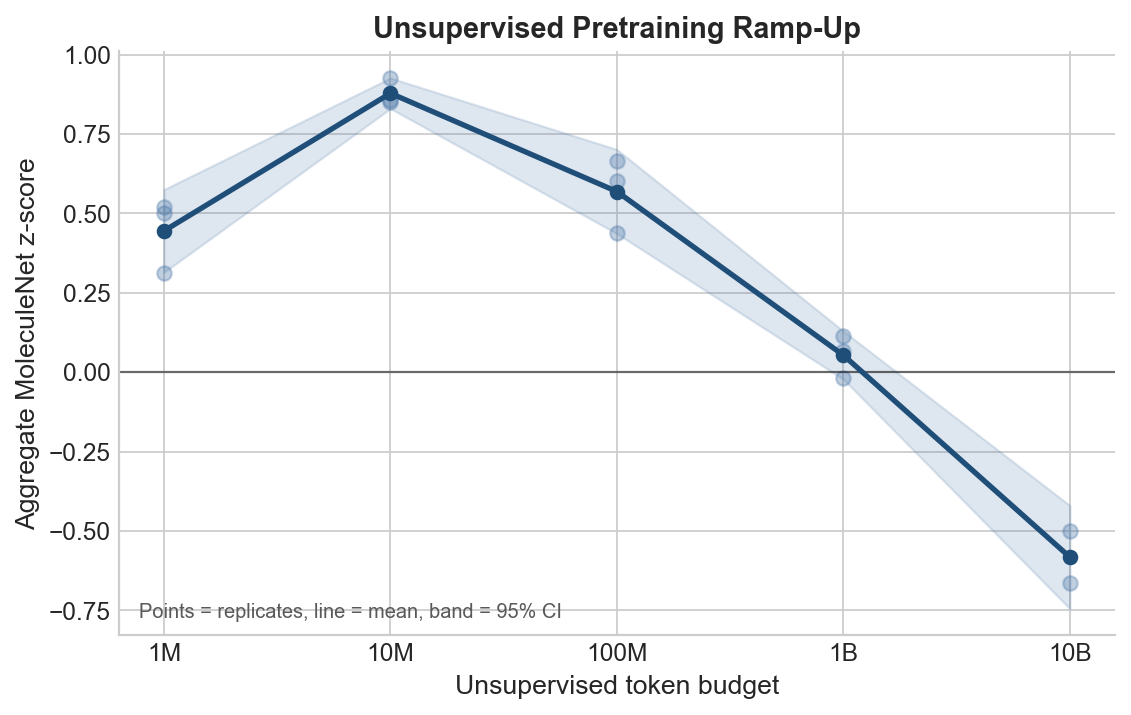

In [8]:
# 1) Unsupervised ramp-up: tokens vs aggregate MoleculeNet z-score
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

RAW = Path("/Users/lsieben/VSCode/CLIMB/experiments/robust_matrix/aggregate/raw_results.csv")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "figure.dpi": 160,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "lines.linewidth": 2.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

HIGHER_IS_BETTER = {"roc_auc"}
LOWER_IS_BETTER = {"rmse"}

df = pd.read_csv(RAW)
df["main_value"] = pd.to_numeric(df["main_value"], errors="coerce")
df = df.dropna(subset=["dataset", "main_metric", "main_value"]).copy()

# Per-dataset z-scores
dataset_stats = (
    df.groupby("dataset")["main_value"]
      .agg(mu="mean", sigma="std")
      .reset_index()
)
df = df.merge(dataset_stats, on="dataset", how="left")
df["z"] = (df["main_value"] - df["mu"]) / df["sigma"].replace(0, np.nan)
df.loc[df["main_metric"].isin(LOWER_IS_BETTER), "z"] *= -1
df["z"] = df["z"].fillna(0.0)

run_scores = (
    df.groupby("run_id", as_index=False)
      .agg(z_score=("z", "mean"),
           num_datasets=("dataset", "nunique"),
           token_budget_total=("token_budget_total", "first"))
)

m = run_scores["run_id"].str.extract(r"^unsup_baseline_(\d+)_(\d+)$")
unsup = run_scores[m[0].notna()].copy()
unsup["tokens"] = m.loc[m[0].notna(), 0].astype(float).values
unsup["replicate"] = m.loc[m[0].notna(), 1].astype(int).values

summary = (
    unsup.groupby("tokens", as_index=False)
         .agg(mean_z=("z_score", "mean"),
              sd_z=("z_score", "std"),
              n=("z_score", "size"))
         .sort_values("tokens")
)
summary["sem_z"] = summary["sd_z"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["sem_z"]

fig, ax = plt.subplots()

# faint replicate points
ax.scatter(
    unsup["tokens"], unsup["z_score"],
    s=42, color="#4C78A8", alpha=0.35, zorder=2
)

# mean trend + CI
ax.plot(summary["tokens"], summary["mean_z"], color="#1F4E79", marker="o", zorder=3)
ax.fill_between(
    summary["tokens"],
    summary["mean_z"] - summary["ci95"],
    summary["mean_z"] + summary["ci95"],
    color="#4C78A8", alpha=0.18, zorder=1
)

ax.set_xscale("log")
ax.set_xlabel("Unsupervised token budget")
ax.set_ylabel("Aggregate MoleculeNet z-score")
ax.set_title("Unsupervised Pretraining Ramp-Up")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e9:.0f}B" if x >= 1e9 else (f"{x/1e6:.0f}M" if x >= 1e6 else f"{int(x):,}"))
)

ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.text(
    0.02, 0.03,
    "Points = replicates, line = mean, band = 95% CI",
    transform=ax.transAxes, fontsize=9, color="0.35"
)

fig.tight_layout()
plt.show()


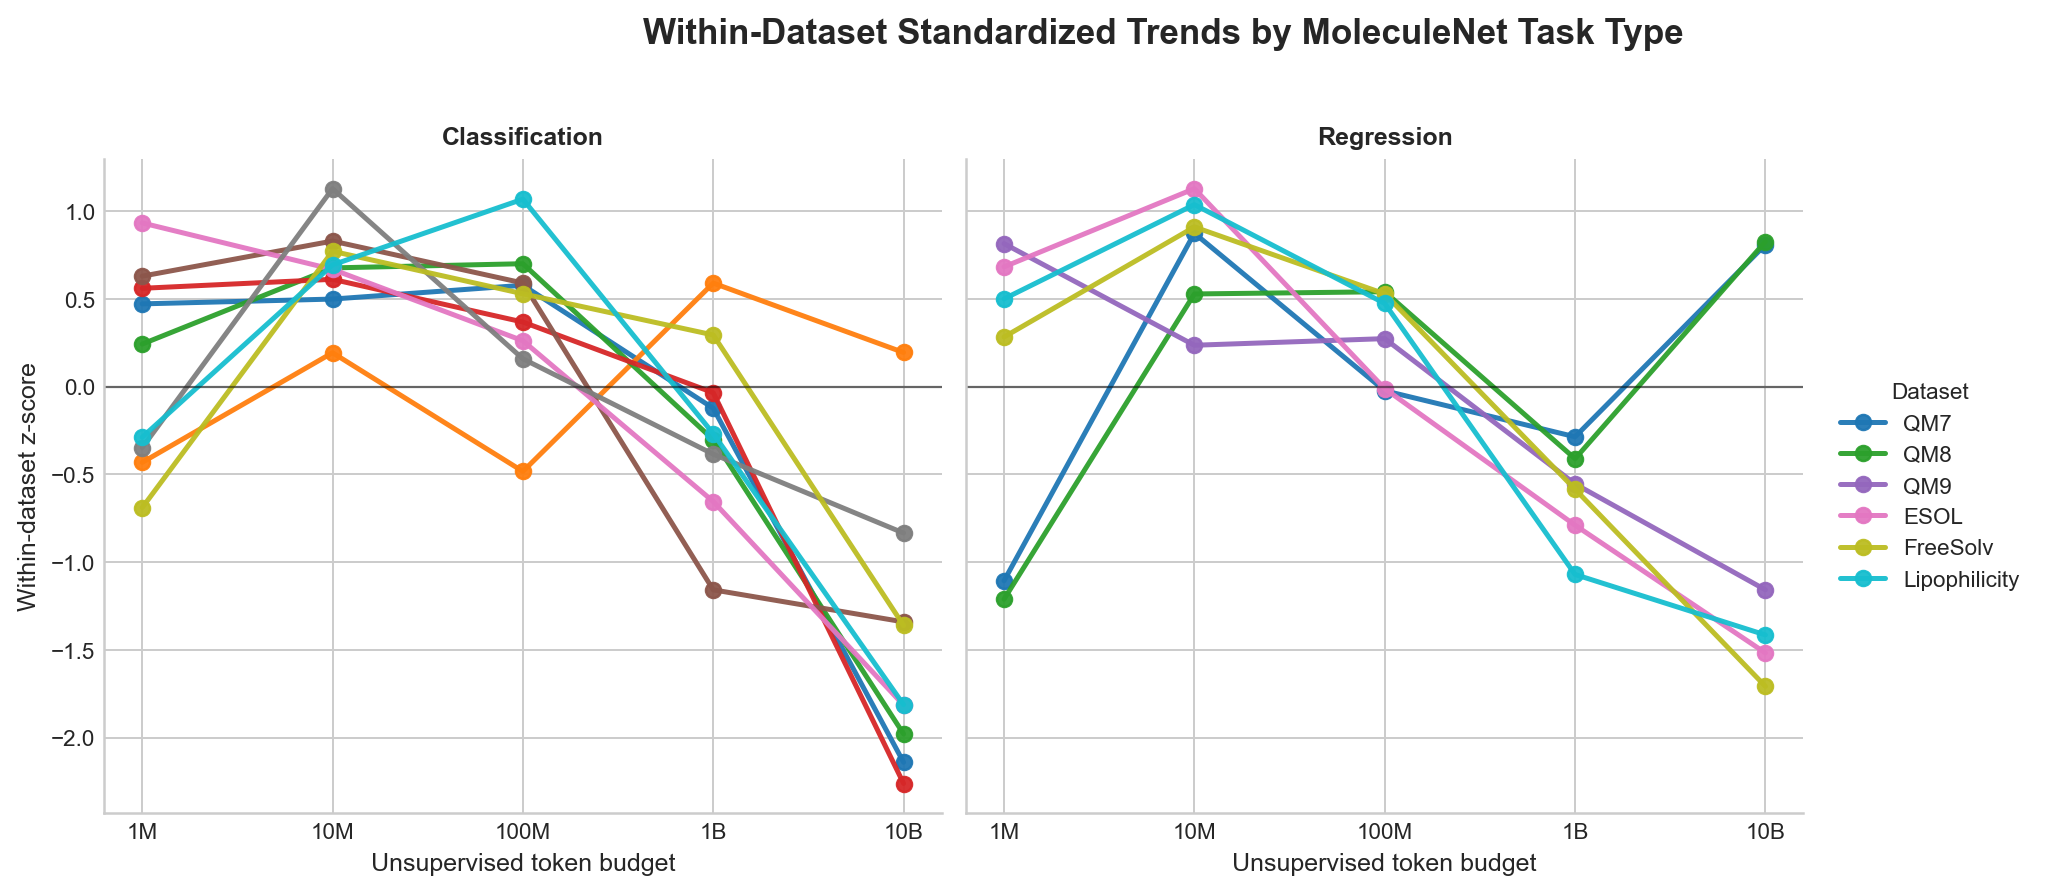

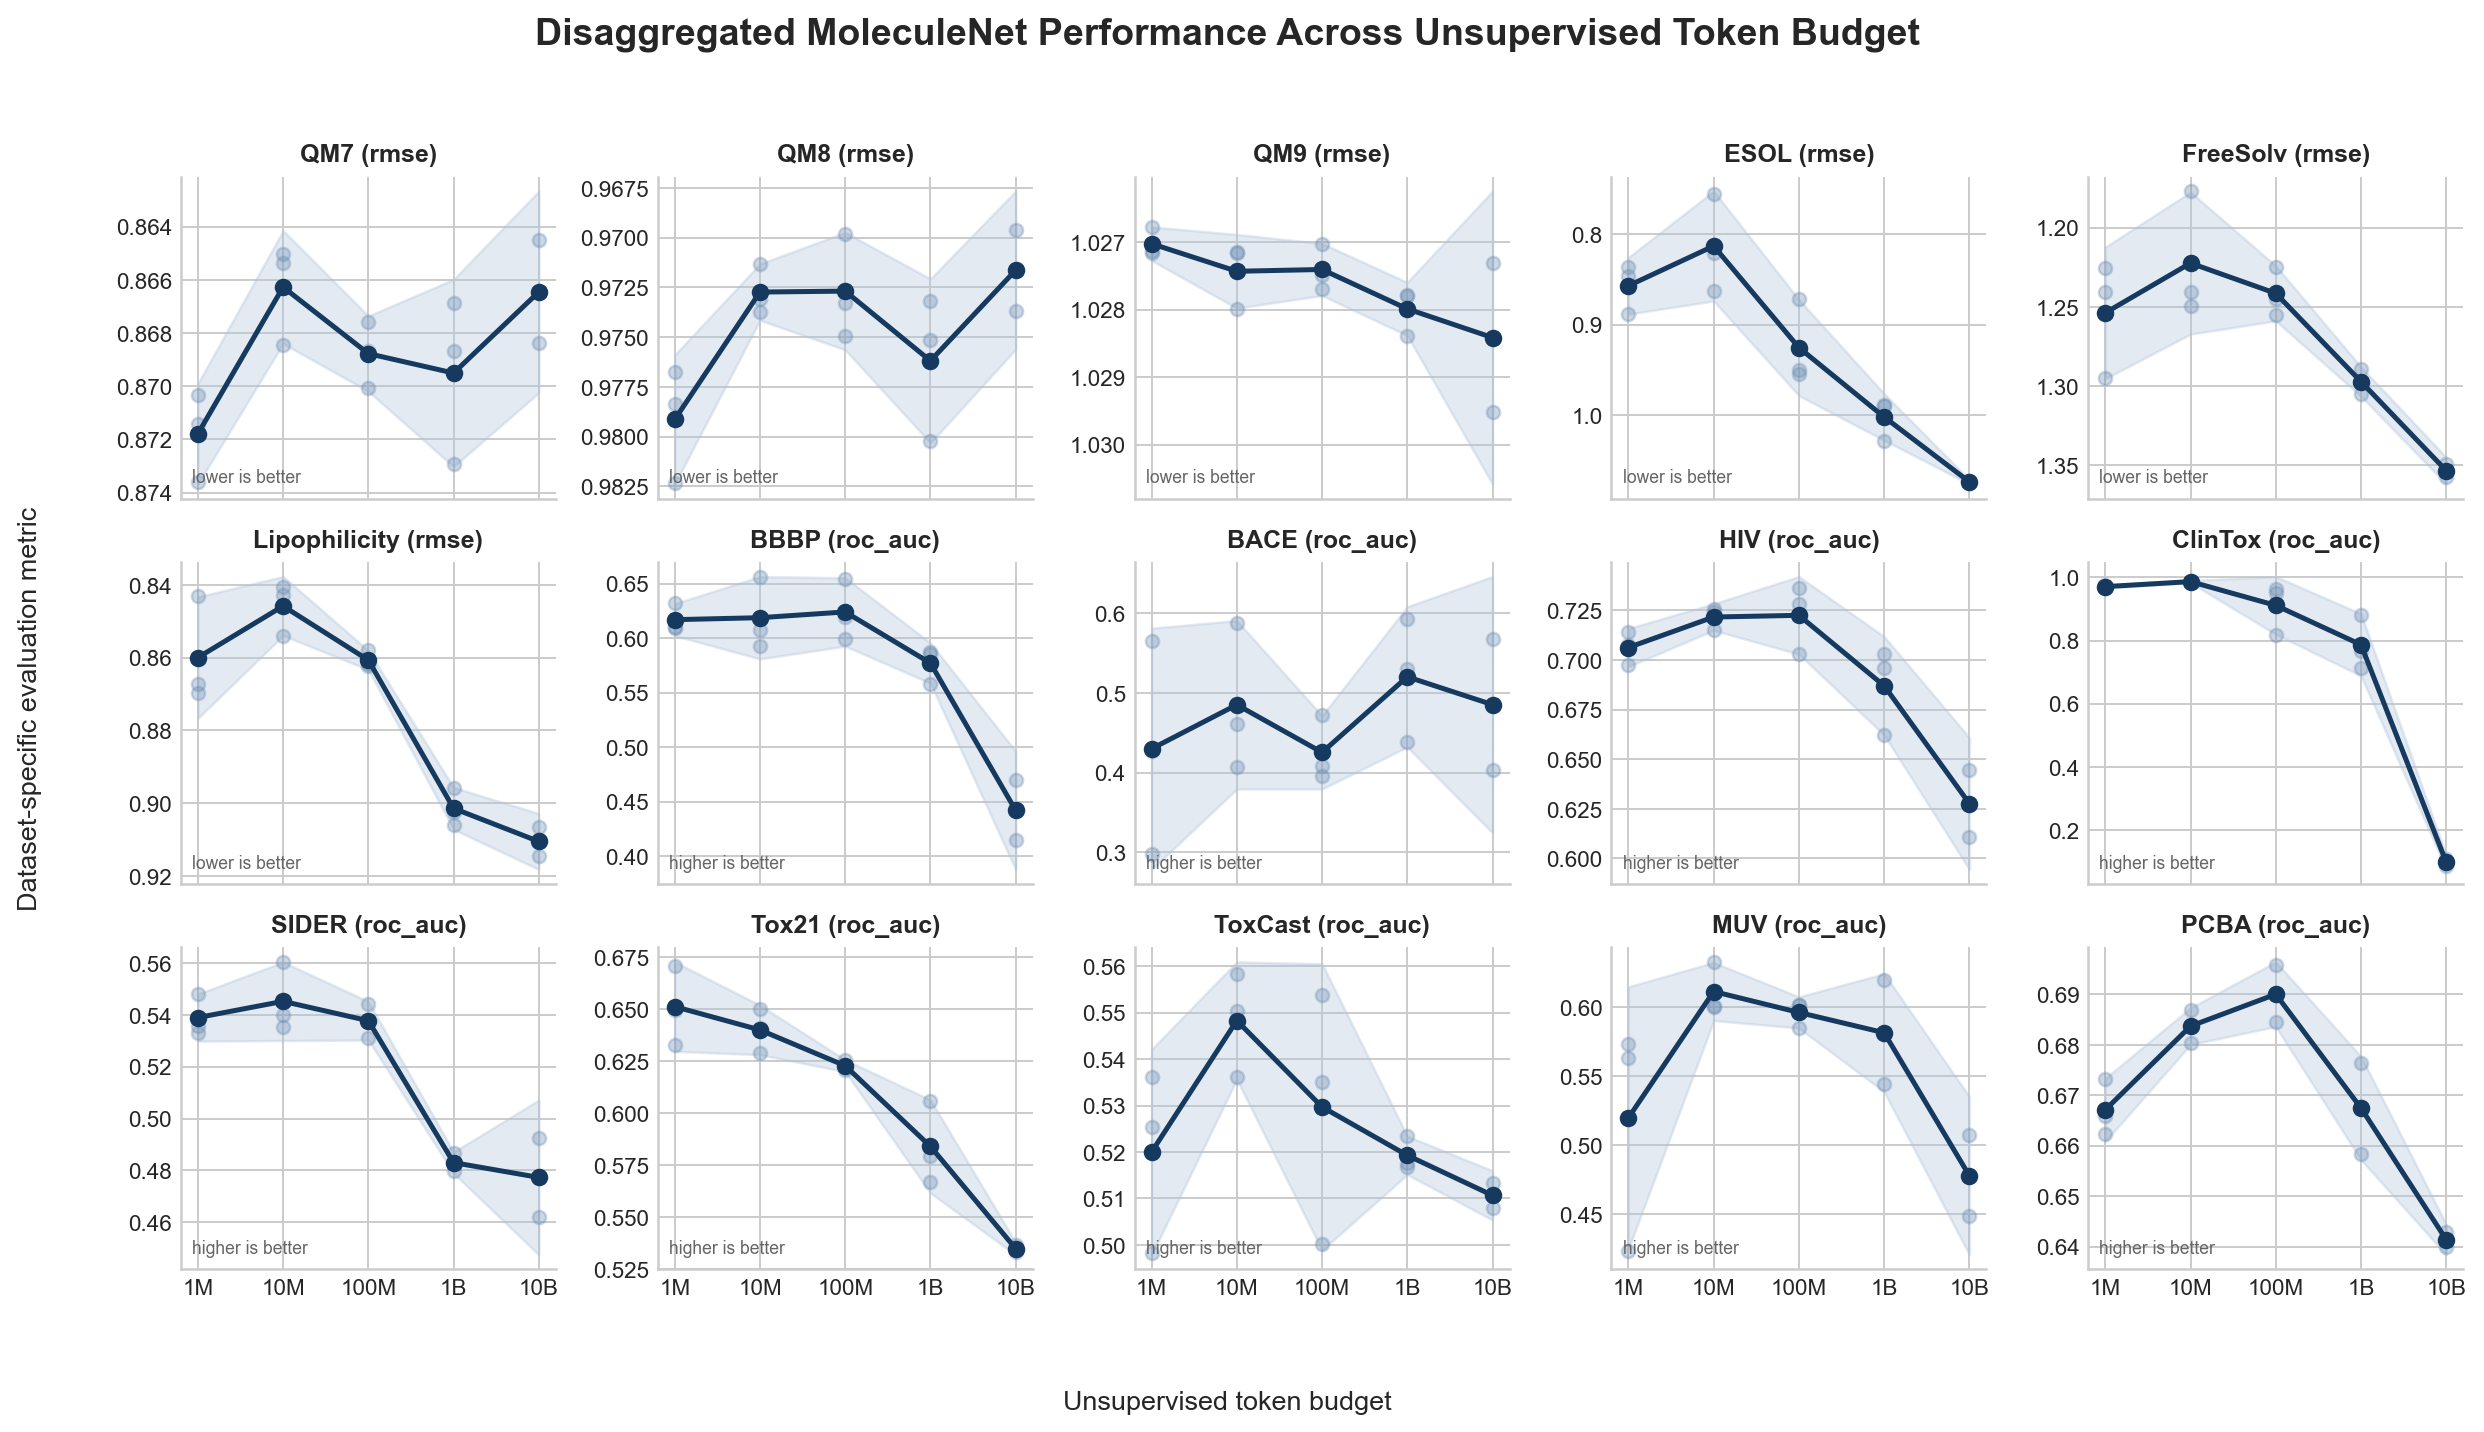

## Supervised Ramp-Up

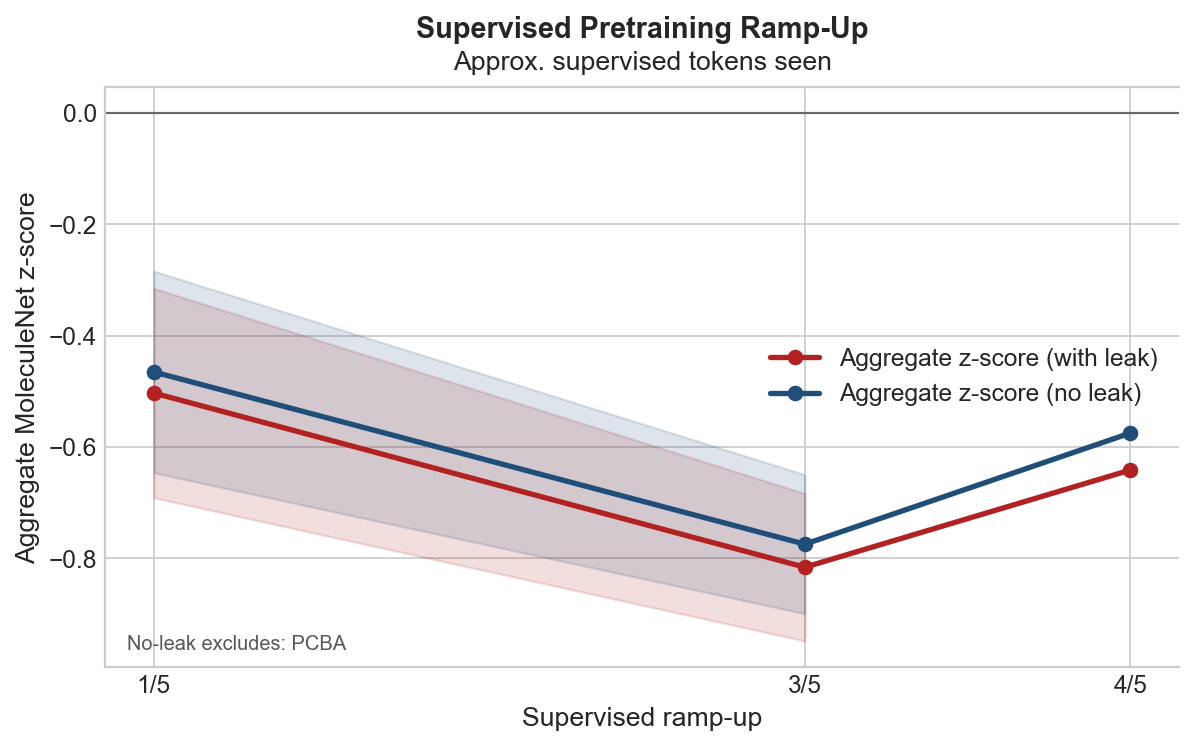

In [9]:
# 2) Supervised ramp-up: 1/5..5/5 on x-axis, with leaked vs no-leak aggregate z-score
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW = Path("/Users/lsieben/VSCode/CLIMB/experiments/robust_matrix/aggregate/raw_results.csv")
LEAKED_DATASETS = {"PCBA"}  # adjust if your leak definition differs

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (7.6, 4.8),
    "figure.dpi": 160,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "lines.linewidth": 2.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

LOWER_IS_BETTER = {"rmse"}

df = pd.read_csv(RAW)
df["main_value"] = pd.to_numeric(df["main_value"], errors="coerce")
df["token_budget_total"] = pd.to_numeric(df["token_budget_total"], errors="coerce")
df = df.dropna(subset=["dataset", "main_metric", "main_value"]).copy()

# Standardize per dataset across all completed runs
stats = df.groupby("dataset")["main_value"].agg(mu="mean", sigma="std").reset_index()
df = df.merge(stats, on="dataset", how="left")
df["z"] = (df["main_value"] - df["mu"]) / df["sigma"].replace(0, np.nan)
df.loc[df["main_metric"].isin(LOWER_IS_BETTER), "z"] *= -1
df["z"] = df["z"].fillna(0.0)

run_meta = (
    df.groupby("run_id", as_index=False)
      .agg(token_budget_total=("token_budget_total", "first"))
)

m = run_meta["run_id"].str.extract(r"^sup_order_(\d)of5_(\d+)$")
sup_runs = run_meta[m[0].notna()].copy()
sup_runs["n_families"] = m.loc[m[0].notna(), 0].astype(int).values
sup_runs["replicate"] = m.loc[m[0].notna(), 1].astype(int).values

all_scores = (
    df[df["run_id"].isin(sup_runs["run_id"])]
    .groupby("run_id", as_index=False)
    .agg(z_all=("z", "mean"))
)

noleak_scores = (
    df[(df["run_id"].isin(sup_runs["run_id"])) & (~df["dataset"].isin(LEAKED_DATASETS))]
    .groupby("run_id", as_index=False)
    .agg(z_no_leak=("z", "mean"))
)

plot_df = sup_runs.merge(all_scores, on="run_id", how="left").merge(noleak_scores, on="run_id", how="left")

summary = (
    plot_df.groupby("n_families", as_index=False)
           .agg(
               mean_all=("z_all", "mean"),
               sd_all=("z_all", "std"),
               mean_nl=("z_no_leak", "mean"),
               sd_nl=("z_no_leak", "std"),
               n=("run_id", "size"),
               tokens=("token_budget_total", "median"),
           )
           .sort_values("n_families")
)
summary["ci_all"] = 1.96 * summary["sd_all"] / np.sqrt(summary["n"])
summary["ci_nl"] = 1.96 * summary["sd_nl"] / np.sqrt(summary["n"])

fig, ax = plt.subplots()

ax.plot(summary["n_families"], summary["mean_all"], marker="o", color="#B22222", label="Aggregate z-score (with leak)")
ax.fill_between(
    summary["n_families"],
    summary["mean_all"] - summary["ci_all"],
    summary["mean_all"] + summary["ci_all"],
    color="#B22222", alpha=0.15
)

ax.plot(summary["n_families"], summary["mean_nl"], marker="o", color="#1F4E79", label="Aggregate z-score (no leak)")
ax.fill_between(
    summary["n_families"],
    summary["mean_nl"] - summary["ci_nl"],
    summary["mean_nl"] + summary["ci_nl"],
    color="#1F4E79", alpha=0.15
)

ax.set_xlabel("Supervised ramp-up")
ax.set_ylabel("Aggregate MoleculeNet z-score")
ax.set_title("Supervised Pretraining Ramp-Up")
ax.set_xticks(summary["n_families"])
ax.set_xticklabels([f"{k}/5" for k in summary["n_families"]])
ax.axhline(0, color="black", lw=1, alpha=0.5)
ax.legend(loc="best")

# top axis with token counts
top = ax.secondary_xaxis("top")
top.set_xticks(summary["n_families"])
top.set_xticklabels([
    f"{t/1e9:.2f}B" if pd.notna(t) else ""
    for t in summary["tokens"]
])
top.set_xlabel("Approx. supervised tokens seen")

ax.text(
    0.02, 0.03,
    f'No-leak excludes: {", ".join(sorted(LEAKED_DATASETS))}',
    transform=ax.transAxes, fontsize=9, color="0.35"
)

fig.tight_layout()
plt.show()


## Combined Performance (3D-Plot)

/var/folders/5s/3v6dxh3160d1tdrchwsnvmz80000gn/T/ipykernel_11920/2614159856.py:122: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


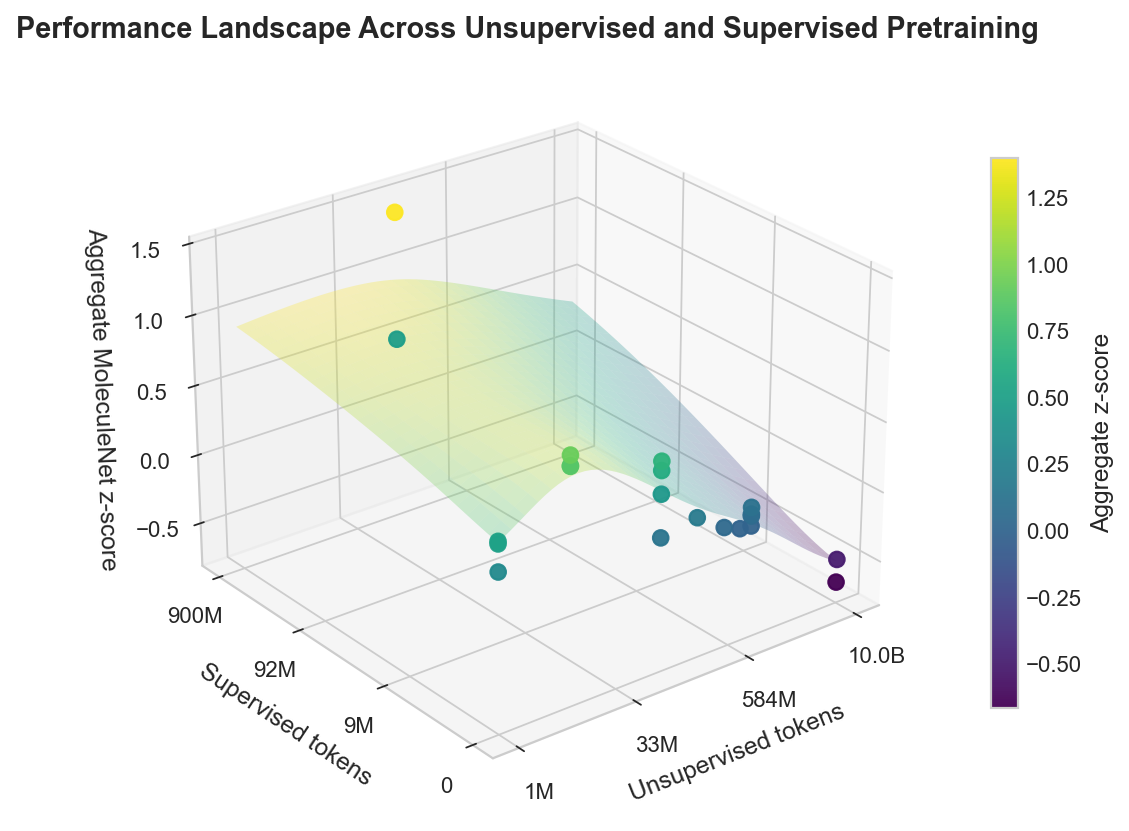

In [10]:
# 3) 3D plot: unsupervised tokens (x), supervised tokens (y), aggregate z-score (z)
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.interpolate import Rbf

RAW = Path("/Users/lsieben/VSCode/CLIMB/experiments/robust_matrix/aggregate/raw_results.csv")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.2, 6.2),
    "figure.dpi": 160,
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

LOWER_IS_BETTER = {"rmse"}

df = pd.read_csv(RAW)
df["main_value"] = pd.to_numeric(df["main_value"], errors="coerce")
df["token_budget_total"] = pd.to_numeric(df["token_budget_total"], errors="coerce")
df = df.dropna(subset=["dataset", "main_metric", "main_value"]).copy()

stats = df.groupby("dataset")["main_value"].agg(mu="mean", sigma="std").reset_index()
df = df.merge(stats, on="dataset", how="left")
df["z"] = (df["main_value"] - df["mu"]) / df["sigma"].replace(0, np.nan)
df.loc[df["main_metric"].isin(LOWER_IS_BETTER), "z"] *= -1
df["z"] = df["z"].fillna(0.0)

runs = (
    df.groupby("run_id", as_index=False)
      .agg(
          z_score=("z", "mean"),
          token_budget_total=("token_budget_total", "first"),
      )
)

def infer_token_coordinates(run_id: str, total_tokens: float):
    # Assumes mixed_<unsup_pct>_<sup_pct>_<rep>; flip these if your naming convention is reversed.
    m = re.match(r"^unsup_baseline_(\d+)_(\d+)$", run_id)
    if m:
        return float(m.group(1)), 0.0

    m = re.match(r"^unsup_cov_(\d+)pct_10b$", run_id)
    if m:
        frac = float(m.group(1)) / 100.0
        return total_tokens * frac, 0.0

    m = re.match(r"^sup_order_(\d)of5_(\d+)$", run_id)
    if m:
        frac = float(m.group(1)) / 5.0
        return 0.0, total_tokens * frac if pd.notna(total_tokens) else np.nan

    m = re.match(r"^mixed_(\d+)_(\d+)_(\d+)$", run_id)
    if m and pd.notna(total_tokens):
        unsup_frac = float(m.group(1)) / 100.0
        sup_frac = float(m.group(2)) / 100.0
        return total_tokens * unsup_frac, total_tokens * sup_frac

    return np.nan, np.nan

coords = runs.apply(
    lambda r: infer_token_coordinates(r["run_id"], r["token_budget_total"]),
    axis=1, result_type="expand"
)
runs["unsup_tokens"] = coords[0]
runs["sup_tokens"] = coords[1]
runs = runs.dropna(subset=["unsup_tokens", "sup_tokens", "z_score"]).copy()

# Log transform for geometry, keep human-readable tick labels
runs["xlog"] = np.log10(runs["unsup_tokens"] + 1e6)
runs["ylog"] = np.log10(runs["sup_tokens"] + 1e6)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    runs["xlog"], runs["ylog"], runs["z_score"],
    c=runs["z_score"], cmap="viridis", s=48, alpha=0.95, depthshade=True
)

# Smooth surface if enough points
if len(runs) >= 8:
    xi = np.linspace(runs["xlog"].min(), runs["xlog"].max(), 55)
    yi = np.linspace(runs["ylog"].min(), runs["ylog"].max(), 55)
    XI, YI = np.meshgrid(xi, yi)
    rbf = Rbf(runs["xlog"], runs["ylog"], runs["z_score"], function="multiquadric", smooth=0.35)
    ZI = rbf(XI, YI)
    ax.plot_surface(XI, YI, ZI, cmap="viridis", alpha=0.28, linewidth=0, antialiased=True)

ax.set_title("Performance Landscape Across Unsupervised and Supervised Pretraining")
ax.set_xlabel("Unsupervised tokens")
ax.set_ylabel("Supervised tokens")
ax.set_zlabel("Aggregate MoleculeNet z-score")
ax.view_init(elev=26, azim=-128)

def token_ticklabel(v):
    t = (10**v) - 1e6
    if t >= 1e9:
        return f"{t/1e9:.1f}B"
    if t >= 1e6:
        return f"{t/1e6:.0f}M"
    return f"{int(t):d}"

xticks = np.linspace(runs["xlog"].min(), runs["xlog"].max(), 4)
yticks = np.linspace(runs["ylog"].min(), runs["ylog"].max(), 4)
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels([token_ticklabel(v) for v in xticks])
ax.set_yticklabels([token_ticklabel(v) for v in yticks])

cbar = fig.colorbar(sc, shrink=0.72, pad=0.08)
cbar.set_label("Aggregate z-score")

fig.tight_layout()
plt.show()


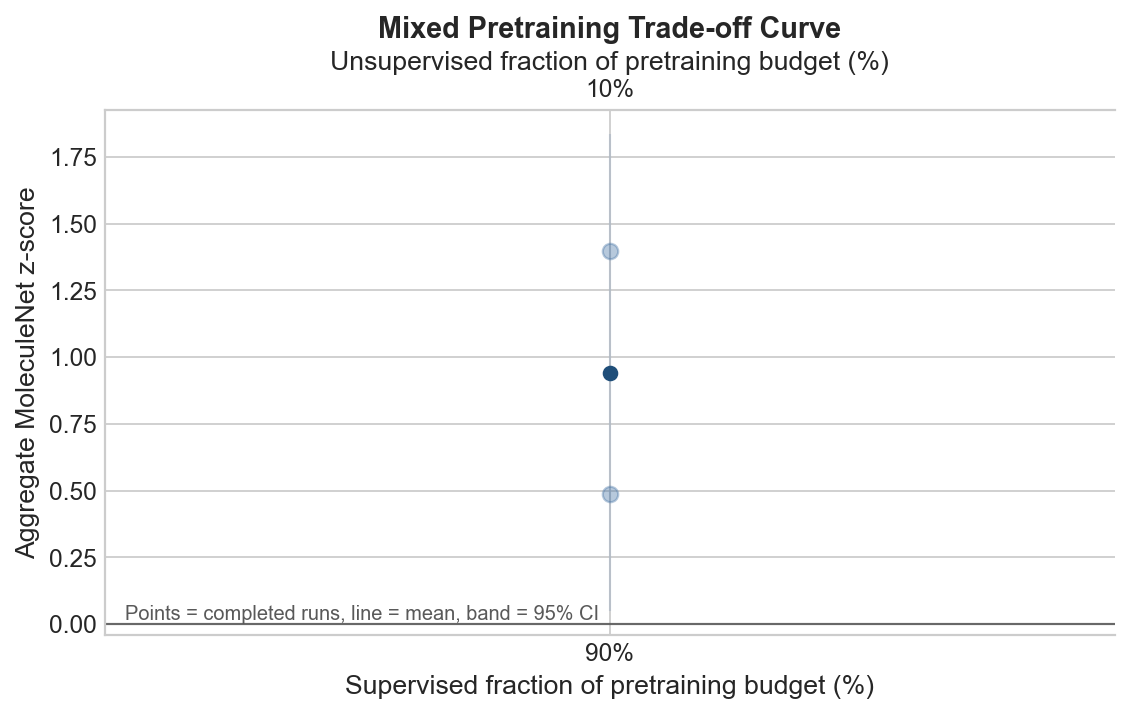

In [11]:
# Mixed-only 2D plot: supervised fraction vs aggregate MoleculeNet z-score
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW = Path("/Users/lsieben/VSCode/CLIMB/experiments/robust_matrix/aggregate/raw_results.csv")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "figure.dpi": 160,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "lines.linewidth": 2.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

LOWER_IS_BETTER = {"rmse"}

df = pd.read_csv(RAW)
df["main_value"] = pd.to_numeric(df["main_value"], errors="coerce")
df = df.dropna(subset=["dataset", "main_metric", "main_value"]).copy()

# Per-dataset z-scores
stats = df.groupby("dataset")["main_value"].agg(mu="mean", sigma="std").reset_index()
df = df.merge(stats, on="dataset", how="left")
df["z"] = (df["main_value"] - df["mu"]) / df["sigma"].replace(0, np.nan)
df.loc[df["main_metric"].isin(LOWER_IS_BETTER), "z"] *= -1
df["z"] = df["z"].fillna(0.0)

run_scores = (
    df.groupby("run_id", as_index=False)
      .agg(z_score=("z", "mean"))
)

m = run_scores["run_id"].str.extract(r"^mixed_(\d+)_(\d+)_(\d+)$")
mixed = run_scores[m[0].notna()].copy()
mixed["unsup_pct"] = m.loc[m[0].notna(), 0].astype(int).values
mixed["sup_pct"] = m.loc[m[0].notna(), 1].astype(int).values
mixed["replicate"] = m.loc[m[0].notna(), 2].astype(int).values

summary = (
    mixed.groupby(["unsup_pct", "sup_pct"], as_index=False)
         .agg(mean_z=("z_score", "mean"),
              sd_z=("z_score", "std"),
              n=("z_score", "size"))
         .sort_values("sup_pct")
)
summary["ci95"] = 1.96 * summary["sd_z"] / np.sqrt(summary["n"])

fig, ax = plt.subplots()

# replicate points
ax.scatter(
    mixed["sup_pct"], mixed["z_score"],
    s=48, color="#4C78A8", alpha=0.4, zorder=2
)

# mean trend
ax.plot(
    summary["sup_pct"], summary["mean_z"],
    marker="o", color="#1F4E79", zorder=3
)
ax.fill_between(
    summary["sup_pct"],
    summary["mean_z"] - summary["ci95"],
    summary["mean_z"] + summary["ci95"],
    color="#4C78A8", alpha=0.18, zorder=1
)

ax.set_xlabel("Supervised fraction of pretraining budget (%)")
ax.set_ylabel("Aggregate MoleculeNet z-score")
ax.set_title("Mixed Pretraining Trade-off Curve")
ax.set_xticks(summary["sup_pct"])
ax.set_xticklabels([f"{x}%" for x in summary["sup_pct"]])
ax.axhline(0, color="black", lw=1, alpha=0.5)

top = ax.secondary_xaxis("top")
top.set_xticks(summary["sup_pct"])
top.set_xticklabels([f"{100-x}%" for x in summary["sup_pct"]])
top.set_xlabel("Unsupervised fraction of pretraining budget (%)")

ax.text(
    0.02, 0.03,
    "Points = completed runs, line = mean, band = 95% CI",
    transform=ax.transAxes, fontsize=9, color="0.35"
)

fig.tight_layout()
plt.show()
